# Graph classification sweep performance 

Plots showing the performance for the graph classification on the CosMx Pancrease data with no diabetes and Type 1 Diabetes conditions.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [68]:
LRZ = "/dss/dsshome1/05/di93tig/1_projects/"
HPC = "/home/icb/francesca.drummer/1-Projects/"
DATA = "melton25"

In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{HPC}InterScale_reproducibility')
sys.path.insert(0, str(project_root))

In [3]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ste sys path correctly
#from src.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_robustness
from src.wandb import Wandb_evaluation, plot_f1_across_seeds

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/u

In [80]:
import yaml
import matplotlib.pyplot as plt

with open(os.path.join(HPC, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Load WandB IDs

In [4]:
GNN_sweep = "6qip4qz4"
InterScale_sweep = "8a7ycqw7"
PCATrans_sweep = "8v6uc6k4"

## Graph Classification performance

In [5]:
SWEEP_GOAL = 'robustness'
CLASSES = ['ND', 'T1D']

Q: Why does PCATrans not have test_f1 scores?

In [6]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, SWEEP_GOAL, CLASSES)
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, CLASSES)

In [14]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1/class_ND,test_f1/class_T1D
0,i05jtbt2,melton25_clas_graph_44_GCN_,44,finished,0.5,150,None,266.588539,255026,0.422389,None,0.580200,0.007663
1,fbqm79ls,melton25_clas_graph_44_GCN_,43,finished,0.5,150,None,1085.586409,255026,0.565265,None,0.632455,0.433916
2,wfmeskot,melton25_clas_graph_44_GCN_,42,finished,0.5,150,None,786.359583,255026,0.573303,None,0.636875,0.428175
3,h5v3ms93,melton25_clas_graph_44_GCN_,41,finished,0.5,150,None,1015.778271,255026,0.561471,None,0.634270,0.408182
4,0qt9z9ue,melton25_clas_graph_44_GCN_,40,finished,0.5,150,None,896.475081,255026,0.575682,None,0.636441,0.451504


In [15]:
PCATrans_wandb.get_mean_and_std()

,pct_mask_nodes,radius,mean_test_acc,std_test_acc,mean_test_f1_class_0,std_test_f1_class_0,mean_test_f1_class_1,std_test_f1_class_1
0,0.0,0,0.535674,0.031392,0.547981,0.125172,0.442152,0.083573
1,0.0,60,0.607047,0.169665,0.586208,0.111104,0.556490,0.287862
2,0.0,110,0.539841,0.122793,0.471813,0.178746,0.487966,0.254383
3,0.0,150,0.539841,0.122793,0.471813,0.178746,0.487966,0.254383
4,0.1,0,0.562286,0.166012,0.427933,0.272471,0.557277,0.257506


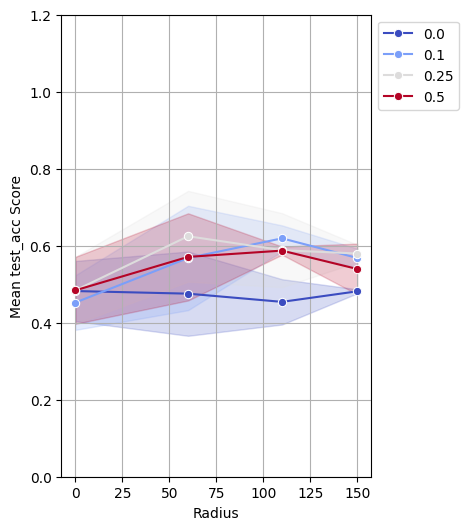

In [17]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/melton25/graph_class")

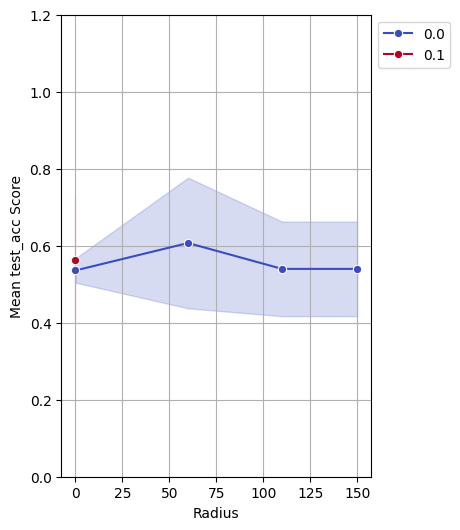

In [18]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/melton25/graph_class")

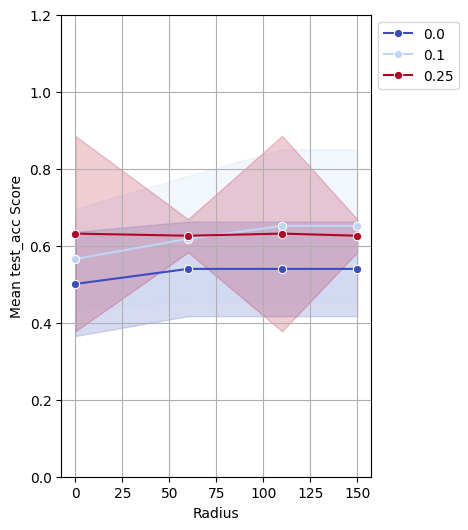

In [19]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/melton25/graph_class")

            model class      mean       std  n_seeds
0             GCN    ND  0.551546  0.001883        5
1             GCN   T1D  0.335773  0.012181        5
2      InterScale    ND  0.471813  0.178746        5
3      InterScale   T1D  0.487966  0.254383        5
4  PCATransformer    ND  0.471813  0.178746        5
5  PCATransformer   T1D  0.487966  0.254383        5


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/icb/francesca.drummer/1-Projects/InterScale_reproducibility/src/wandb.py:379: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


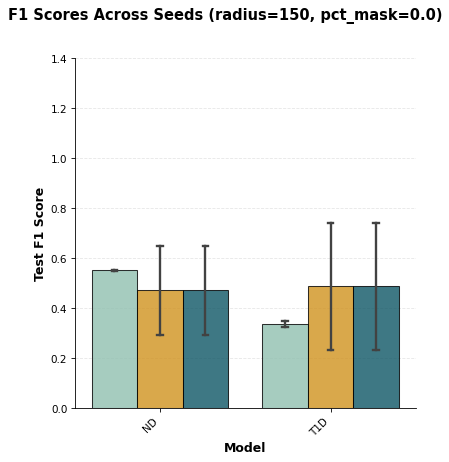

In [25]:
wandb_evals = [GNN_wandb, PCATrans_wandb, InterScale_wandb]  # Your list of dataframes

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=150,
    pct_mask_nodes=0.0,
    config_path='config.yml',
    height=6,
    aspect=0.9
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

# Interpretation of CLS token

Given the sweep, we obtain the best model and check the CLS token.

In [91]:
from InterScale.evaluation.graph_classification import scale_cls_by_sample#, plot_adata_grouped_heatmaps
import squidpy as sq

In [51]:
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, CLASSES)

In [103]:
import InterScale as interscale

combined_model, model_config, adata = InterScale_wandb.load_model("test_f1/class_T1D")


Cleaned config loaded
dataset:
  batch_size: 32
  description: 
  group_label: None
  h5ad_data: /lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/cosmx_pancreas.h5ad
  layer_key: None
  name: melton25
  num_classes: -1
  num_features: -1
  pct_mask_nodes: 0.1
  prediction_level: graph
  prediction_obs: condition
  prediction_task: classification
  sample_key: ['sliding_window_square', 'sliding_window_v']
  segmentation_robustness: None
  spatial_neigbors_kwargs:
    coord_type: generic
    library_key: slide_fov
    n_neighs: 6
    radius: 110
  split_key: split
  stratify_group: None
  test_size: 0.1
  train_size: 0.7
  val_size: 0.2
dataset.pct_mask_nodes: 0.1
dataset.spatial_neigbors_kwargs.radius: 150
model:
  decoder:
    dropout_decoder: 0.1
    hidden_dims: [256, 128]
    type: linear
  global_component:
    load: None
    name: self-attn-transformer
    parameters:
      activation_func: relu
      dim_feedforward: 256
      dropout_global: 0.3
  

wandb:   1 of 1 files downloaded.  


Model artifact downloaded to: /ictstr01/home/icb/francesca.drummer/1-Projects/InterScale_reproducibility/notebooks/melton_jimenez_25/artifacts/model-amqw6ou2:v0


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


WeightedCE with class weights:  tensor([1.1977, 0.8583], dtype=torch.float64)
Loading model from /ictstr01/home/icb/francesca.drummer/1-Projects/InterScale_reproducibility/notebooks/melton_jimenez_25/artifacts/model-amqw6ou2:v0/modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown
Model loaded successfully from run: amqw6ou2


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [95]:
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_prediction_obs', '_scvi_split_key'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
 

In [104]:
result_t1d = combined_model.get_model_output(adata[adata.obs['condition'] == 'T1D'], prefix = 'combined')
result_nd = combined_model.get_model_output(adata[adata.obs['condition'] == 'ND'], prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .X
call new
{'condition': ['T1D']}
INFO     Received view of anndata, making copy.                                                                    


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .X
call new
{'condition': ['ND']}


In [105]:
scale_cls_by_sample(result_t1d, 'sliding_window_square')
scale_cls_by_sample(result_nd, "sliding_window_square")

NameError: name 'pd' is not defined

In [ ]:
GROUP = 'cell_type_coarse'
fig = plot_adata_grouped_heatmaps(
        adata_dict={'ND': result_nd, 'T1D': result_t1d},
        group_by=GROUP,
        #value_cols=['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled'],
    agg_func='mean',
        figsize=(10, 8),
        save_path=f"{HPC}/InterScale_reproducibility/figures/{DATA}/graph_class/cls_{GROUP}.png"
    )

In [ ]:
# assign cell type colors
color_list = [CELL_TYPE_COLORS[ct] for ct in adata.obs[GROUP].cat.categories]
result_t1d.uns[f'{GROUP}_colors'] = color_list
result_nd.uns[f'{GROUP}_colors'] = color_list

In [ ]:
image_nr_long = np.unique(result_t1d.obs['slide_fov'][result_t1d.obs['split'] == 'test'])
image_subset = list(np.random.choice(image_nr_long, 2))
sq.pl.spatial_scatter(result_t1d[result_t1d.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', GROUP],
                      library_key = 'slide_fov',
                      library_id = image_subset,
                    cmap = PALETTE,
                    shape= None,
                      ncols = 3,
                      size = 50,
                      save = f"{HPC}/InterScale_reproducibility/figures/{DATA}/graph_class/"
)

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from typing import List, Dict, Optional, Union

def plot_adata_grouped_heatmaps(
    adata_dict: Dict[str, 'AnnData'],
    group_by: str,
    value_cols: List[str] = None,
    labels: List[str] = None,
    split_key: Optional[str] = 'split',
    split_value: Optional[str] = 'test',
    figsize: tuple = (10, 6),
    save_path: Optional[str] = None,
    cmap: str = 'viridis_r',
    annot: bool = True,
    fmt: str = '.2f',
    linewidth: float = 0.5,
    shared_colorbar: bool = True,
    agg_func: str = 'mean',
    **kwargs
) -> plt.Figure:
    """
    Create side-by-side heatmaps from multiple AnnData objects with shared color scale.
    
    Parameters
    ----------
    adata_dict : Dict[str, AnnData]
        Dictionary with keys as condition names and values as AnnData objects.
        Order of keys determines subplot order.
    group_by : str
        Column name in adata.obs to group by (e.g., 'CellType', 'cluster').
    value_cols : List[str], optional
        List of column names to aggregate. If None, defaults to:
        ['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled']
    labels : List[str], optional
        Subplot titles. If None (default), automatically uses keys from adata_dict.
    split_key : str, optional
        Column name for filtering (e.g., 'split'). Set to None to skip filtering.
    split_value : str, optional
        Value to filter on (e.g., 'test'). Only used if split_key is not None.
    figsize : tuple, default (10, 6)
        Figure size (width, height).
    save_path : str, optional
        Path to save figure. If None, figure is not saved.
    cmap : str, default 'viridis_r'
        Colormap name.
    annot : bool, default True
        Whether to annotate heatmap cells with values.
    fmt : str, default '.2f'
        Format string for annotations.
    linewidth : float, default 0.5
        Width of lines dividing cells.
    shared_colorbar : bool, default True
        Whether to use a shared colorbar (only on last subplot).
    agg_func : str, default 'mean'
        Aggregation function ('mean', 'median', 'sum', etc.).
    **kwargs
        Additional keyword arguments passed to sns.heatmap.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object.
    
    Examples
    --------
    >>> # Basic usage - subplot titles automatically use dict keys ('ND', 'Onset', 'Long')
    >>> adata_dict = {
    ...     'ND': result_nd,
    ...     'Onset': result_onset,
    ...     'Long': result_long
    ... }
    >>> fig = plot_adata_grouped_heatmaps(
    ...     adata_dict=adata_dict,
    ...     group_by='CellType',
    ...     save_path='output/cls_heatmap.png'
    ... )
    
    >>> # Custom columns and no filtering - titles use dict keys
    >>> fig = plot_adata_grouped_heatmaps(
    ...     adata_dict={'Control': adata1, 'Treatment': adata2},
    ...     group_by='cell_type',
    ...     value_cols=['gene_A', 'gene_B', 'gene_C'],
    ...     split_key=None,
    ...     figsize=(12, 5)
    ... )
    
    >>> # Only use custom labels if you want titles different from dict keys
    >>> fig = plot_adata_grouped_heatmaps(
    ...     adata_dict={'cond1': adata1, 'cond2': adata2},
    ...     group_by='CellType',
    ...     labels=['Control Group', 'Treatment Group']  # Optional override
    ... )
    """
    # Set default value columns if not provided
    if value_cols is None:
        value_cols = ['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled']
    
    # Use dict keys as labels if not provided (default behavior)
    if labels is None:
        labels = list(adata_dict.keys())
    else:
        # Validate if custom labels are provided
        if len(labels) != len(adata_dict):
            raise ValueError(f"Number of labels ({len(labels)}) must match number of AnnData objects ({len(adata_dict)})")
    
    # Process each AnnData object and compute aggregated data
    processed_data = {}
    for key, adata in adata_dict.items():
        # Filter by split if specified
        if split_key is not None and split_value is not None:
            if split_key not in adata.obs.columns:
                raise KeyError(f"Column '{split_key}' not found in adata.obs for '{key}'")
            adata_filtered = adata[adata.obs[split_key] == split_value]
        else:
            adata_filtered = adata
        
        # Check if group_by column exists
        if group_by not in adata_filtered.obs.columns:
            raise KeyError(f"Column '{group_by}' not found in adata.obs for '{key}'")
        
        # Check if value columns exist
        for col in value_cols:
            if col not in adata_filtered.obs.columns:
                raise KeyError(f"Column '{col}' not found in adata.obs for '{key}'")
        
        # Create aggregation dictionary
        agg_dict = {f'mean_{col}': (col, agg_func) for col in value_cols}
        
        # Group and aggregate
        processed_data[key] = adata_filtered.obs.groupby(group_by).agg(**agg_dict)
    
    # Calculate shared color scale
    all_values = np.concatenate([df.values.flatten() for df in processed_data.values()])
    vmin = all_values.min()
    vmax = all_values.max()
    
    # Create figure with subplots
    n_plots = len(processed_data)
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    
    # Handle case of single subplot
    if n_plots == 1:
        axes = [axes]
    
    # Plot each heatmap
    for idx, (key, label) in enumerate(zip(adata_dict.keys(), labels)):
        data = processed_data[key]
        
        # Determine if this is the last plot (for colorbar)
        show_cbar = shared_colorbar and (idx == n_plots - 1)
        
        sns.heatmap(
            data,
            annot=annot,
            linewidth=linewidth,
            fmt=fmt,
            ax=axes[idx],
            vmin=vmin,
            vmax=vmax,
            cbar=show_cbar,
            cmap=cmap,
            **kwargs
        )
        axes[idx].set_title(label)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig